# Machine Learning — Naive Bayes

## Beginner-Friendly Practical Notebook

**Topics covered**
- Business problem
- Bayes theorem
- Why Naive Bayes is called "Naive"
- Types of Naive Bayes
- Numerical classification with `GaussianNB`
- Text classification with `MultinomialNB`
- Evaluation metrics
- Prediction probabilities
- Laplace smoothing
- Business case study
- Practice exercises
- Interview questions


https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/

## 1. Business Problem

Imagine an e-commerce company wants to predict whether a customer will purchase a product.

We have:
- **Age**
- **Income**

Target:
- `0` → No Purchase
- `1` → Purchase

This is a **supervised classification problem**.

Naive Bayes is also widely used for text classification such as spam detection, sentiment analysis, and document classification.


## 2. What is Naive Bayes?

**Naive Bayes is a supervised machine-learning classification algorithm based on Bayes' theorem.**

It calculates the probability that an observation belongs to a class based on the available features.

The key idea is:

> Prior probability + Evidence → Updated probability

Naive Bayes makes a simplifying assumption that features are conditionally independent given the class.


## 3. Bayes Theorem

Bayes theorem is used to update the probability of an event when new evidence becomes available.

Conceptually:

**P(Class | Features)**

means:

> Probability of a class given the observed features.

For example:

**P(Purchase | Age, Income)**

asks: "What is the probability that this customer will purchase, given their age and income?"


## 4. Why is it called "Naive"?

Suppose an email contains these words:

- free
- money
- offer
- win

Naive Bayes assumes these features are conditionally independent given the class.

In real life, these words may be related, so the assumption is called **naive**.

Despite this simplification, Naive Bayes can perform very well, especially for text classification.


## 5. Types of Naive Bayes

| Algorithm | Typical Use |
|---|---|
| `GaussianNB` | Continuous numerical data |
| `MultinomialNB` | Word counts / text classification |
| `BernoulliNB` | Binary features |

Examples:

- Age, salary, height → `GaussianNB`
- Word counts → `MultinomialNB`
- Contains word = yes/no → `BernoulliNB`


## 6. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

from sklearn.feature_extraction.text import CountVectorizer


## 7. Create a Customer Purchase Dataset

In [4]:
data = {
    "Age": [
        22, 25, 28, 30, 35,
        40, 45, 50, 55, 60,
        23, 27, 32, 38, 43,
        48, 52, 58, 62, 65
    ],
    "Income": [
        25000, 28000, 32000, 35000, 40000,
        50000, 55000, 60000, 65000, 70000,
        27000, 30000, 37000, 45000, 52000,
        58000, 62000, 68000, 72000, 75000
    ],
    "Purchase": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        0, 0, 0, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
df.head()


,Age,Income,Purchase
0,22,25000,0
1,25,28000,0
2,28,32000,0
3,30,35000,0
4,35,40000,0


## 8. Understand the Dataset

In [5]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())


Shape: (20, 3)

Data types:
Age         int64
Income      int64
Purchase    int64
dtype: object

Missing values:
Age         0
Income      0
Purchase    0
dtype: int64

Summary statistics:


,Age,Income,Purchase
count,20.000000,20.000000,20.000000
mean,41.900000,49300.000000,0.600000
std,13.901533,16648.375928,0.502625
min,22.000000,25000.000000,0.000000
25%,29.500000,34250.000000,0.000000
50%,41.500000,51000.000000,1.000000
75%,52.750000,62750.000000,1.000000
max,65.000000,75000.000000,1.000000


## 9. Separate Features and Target

In [6]:
X = df[["Age", "Income"]]
y = df["Purchase"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())


Features:


,Age,Income
0,22,25000
1,25,28000
2,28,32000
3,30,35000
4,35,40000


Target:


0    0
1    0
2    0
3    0
4    0
Name: Purchase, dtype: int64

## 10. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (15, 2)
Testing data: (5, 2)


## 11. Train Gaussian Naive Bayes

In [10]:
model = GaussianNB()
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


## 12. Make Predictions

In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})
comparison

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1


## 13. Accuracy

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")


Accuracy: 100.00%


## 14. Confusion Matrix

Confusion Matrix:
[[2 0]
 [0 3]]


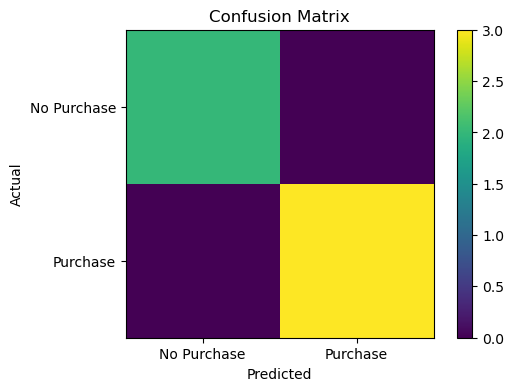

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.yticks([0, 1], ["No Purchase", "Purchase"])

plt.show()


## 15. Classification Report

The classification report contains:

- **Precision** — Of the observations predicted as a class, how many were actually that class?
- **Recall** — Of the observations actually belonging to a class, how many did the model identify?
- **F1-score** — Harmonic mean of precision and recall.
- **Support** — Number of actual observations in each class.


In [17]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



## 16. Predict a New Customer

In [20]:
new_customer = pd.DataFrame({"Age": [33],"Income": [42000]})
prediction = model.predict(new_customer)
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Customer is predicted to PURCHASE.")
else:
    print("Customer is predicted NOT to purchase.")


Prediction: 0
Customer is predicted NOT to purchase.


## 17. Prediction Probability

In [ ]:
probability = model.predict_proba(new_customer)

probability_df = pd.DataFrame(probability,columns=["P(No Purchase)", "P(Purchase)"])
probability_df

,P(No Purchase),P(Purchase)
0,0.916191,0.083809


## 18. Class Prior Probabilities

In [22]:
print("Classes:", model.classes_)
print("Class prior probabilities:", model.class_prior_)


Classes: [0 1]
Class prior probabilities: [0.4 0.6]


## 19. Text Classification with Multinomial Naive Bayes

Naive Bayes is especially useful for text classification.

Example problem:

| Message | Label |
|---|---|
| Win free money now | Spam |
| Claim your free prize | Spam |
| Free lottery offer | Spam |
| You won free cash | Spam |
| Meeting at 5 PM | Not Spam |
| Send me the report | Not Spam |
| Project meeting tomorrow | Not Spam |
| Please send the document | Not Spam |

Machine-learning models need numerical input, so we first convert text into numerical features using `CountVectorizer`.


In [23]:
messages = [
    "win free money now",
    "claim your free prize",
    "free lottery offer",
    "you won free cash",
    "meeting at 5 pm",
    "send me the report",
    "project meeting tomorrow",
    "please send the document"
]

labels = [
    "spam",
    "spam",
    "spam",
    "spam",
    "not spam",
    "not spam",
    "not spam",
    "not spam"
]

text_df = pd.DataFrame({
    "Message": messages,
    "Label": labels
})

text_df


,Message,Label
0,win free money now,spam
1,claim your free prize,spam
2,free lottery offer,spam
3,you won free cash,spam
4,meeting at 5 pm,not spam
5,send me the report,not spam
6,project meeting tomorrow,not spam
7,please send the document,not spam


## 20. Convert Text into Numbers

In [24]:
vectorizer = CountVectorizer()

X_text = vectorizer.fit_transform(messages)

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumerical matrix shape:", X_text.shape)


Vocabulary:
['at' 'cash' 'claim' 'document' 'free' 'lottery' 'me' 'meeting' 'money'
 'now' 'offer' 'please' 'pm' 'prize' 'project' 'report' 'send' 'the'
 'tomorrow' 'win' 'won' 'you' 'your']

Numerical matrix shape: (8, 23)


## 21. View the Bag-of-Words Matrix

In [25]:
bow_df = pd.DataFrame(
    X_text.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df


,at,cash,claim,document,free,lottery,me,meeting,money,now,...,prize,project,report,send,the,tomorrow,win,won,you,your
0,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,0,0,0,0,0
6,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0


## 22. Train Multinomial Naive Bayes

In [26]:
text_model = MultinomialNB()

text_model.fit(X_text, labels)

print("Text classification model trained.")


Text classification model trained.


## 23. Predict a New Message

In [27]:
new_messages = [
    "free money prize",
    "please send the project report"
]

new_vectors = vectorizer.transform(new_messages)

predictions = text_model.predict(new_vectors)

for message, prediction in zip(new_messages, predictions):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}")
    print()


Message: free money prize
Prediction: spam

Message: please send the project report
Prediction: not spam



## 24. Text Prediction Probabilities

In [30]:
text_probabilities = text_model.predict_proba(new_vectors)

probability_df = pd.DataFrame(text_probabilities,columns=text_model.classes_,index=new_messages)
probability_df

,not spam,spam
free money prize,0.051382,0.948618
please send the project report,0.987991,0.012009


## 25. Laplace Smoothing

A zero-frequency problem can occur when a feature has never appeared in a particular class.

Naive Bayes commonly handles this with smoothing.

In scikit-learn:

```python
MultinomialNB(alpha=1.0)
```

The `alpha` parameter controls additive smoothing.


In [31]:
smoothed_model = MultinomialNB(alpha=1.0)
smoothed_model.fit(X_text, labels)

smoothed_predictions = smoothed_model.predict(new_vectors)

for message, prediction in zip(new_messages, smoothed_predictions):
    print(f"{message} -> {prediction}")


free money prize -> spam
please send the project report -> not spam


## 26. Business Case Study — Spam Detection

### Problem

An email provider receives thousands of messages every day.

The goal is to classify messages as:

- Spam
- Not Spam

### Pipeline

```text
Raw Email
   ↓
Text Cleaning
   ↓
CountVectorizer / TF-IDF
   ↓
Multinomial Naive Bayes
   ↓
Spam / Not Spam
```

### Business benefit

The model can automatically prioritize or filter potentially unwanted messages.


## 27. Advantages of Naive Bayes

- Simple
- Fast
- Easy to implement
- Works well with relatively small datasets
- Handles high-dimensional feature spaces
- Strong baseline for text classification
- Fast training and prediction


## 28. Limitations of Naive Bayes

- Conditional-independence assumption may not reflect reality
- Probability estimates can sometimes be poorly calibrated
- Performance can suffer when features have strong dependencies
- Unseen feature/class combinations can create zero-frequency issues without smoothing


## 29. When Should You Use Naive Bayes?

Naive Bayes is worth considering when you have:

- A classification problem
- Many features
- A need for fast training
- Text or count-based features
- A useful simple baseline

Common applications:

- Spam detection
- Sentiment analysis
- News classification
- Document classification
- Customer complaint classification
- Support-ticket classification


## 30. Practice — Customer Purchase Prediction

### Classwork

Using the customer dataset:

1. Find the number of customers who purchased.
2. Find the average age.
3. Find the average income.
4. Train a Gaussian Naive Bayes model.
5. Calculate accuracy.
6. Generate a confusion matrix.
7. Predict whether a 29-year-old customer earning ₹35,000 will purchase.
8. Display the prediction probability.


In [32]:
# Your solution here

# 1. Number of customers who purchased
# 2. Average age
# 3. Average income
# 4. Train model
# 5. Accuracy
# 6. Confusion matrix
# 7. Predict new customer
# 8. Probability


## 31. Practice — Spam Classifier

Build a spam classifier using:

```text
CountVectorizer
+
MultinomialNB
```

Requirements:

1. Create at least 20 messages.
2. Label each message as `spam` or `not spam`.
3. Split the data into training and testing sets.
4. Train the model.
5. Calculate accuracy.
6. Generate a confusion matrix.
7. Generate a classification report.
8. Test at least 5 new messages.
9. Display prediction probabilities.


In [33]:
# Your solution here


## 32. Interview Questions

### Q1. What is Naive Bayes?
A supervised classification algorithm based on Bayes' theorem that assumes conditional independence between features given the class.

### Q2. Why is it called Naive?
Because of its simplifying conditional-independence assumption.

### Q3. What are the common types?
`GaussianNB`, `MultinomialNB`, and `BernoulliNB`.

### Q4. Which Naive Bayes is commonly used for text classification?
`MultinomialNB` is commonly used with count-based text features.

### Q5. When can GaussianNB be useful?
For continuous numerical features when a Gaussian distribution is a reasonable assumption.

### Q6. What is Laplace smoothing?
A technique that prevents zero probabilities for unseen feature/class combinations.

### Q7. Is Naive Bayes supervised or unsupervised?
Supervised learning.

### Q8. Is Naive Bayes mainly classification or regression?
It is primarily used for classification.


# 33. Final Recap

```text
Naive Bayes
│
├── Supervised Learning
├── Classification
├── Based on Bayes' theorem
├── Conditional-independence assumption
│
├── GaussianNB
│     └── Continuous numerical features
│
├── MultinomialNB
│     └── Counts / text classification
│
└── BernoulliNB
      └── Binary features
```

### Practical mapping

| Data | Model |
|---|---|
| Continuous numerical features | `GaussianNB` |
| Word/count features | `MultinomialNB` |
| Binary features | `BernoulliNB` |

**Next project:** Build a complete Spam Email Classifier using `CountVectorizer + MultinomialNB`, then evaluate it using accuracy, precision, recall, F1-score, and a confusion matrix. ( in Deep Learning)